In [12]:
# =============================================================================
# NOTEBOOK 02: QWEN2.5-VL-3B + XAI (4 METHODS)
# Đề tài: Triển khai Qwen cho phát hiện & phân loại tế bào kết hợp XAI
# Nhóm: Nguyễn Quốc Vinh · Hồ Nhật Hào · Lê Trần Quốc Huy
# Platform: Kaggle Notebook — GPU T4 x2
# Dataset: Dataset-Crop (12 loại tế bào, ảnh đã crop sẵn)
# Model: Qwen/Qwen2.5-VL-3B-Instruct + LoRA 4-bit
# XAI: HiresCAM · XGrad-CAM · EigenCAM · Integrated Gradients
# =============================================================================
# TRƯỚC KHI CHẠY:
# 1. Settings → Accelerator → "GPU T4 x2"
# 2. Dataset ChuDe4 đã add sẵn (Dataset-Crop/)
# 3. Settings → Internet → ON (để download Qwen weights)
# =============================================================================


# %%
# ============================================================
# CELL 1: CÀI ĐẶT THƯ VIỆN
# ============================================================
import subprocess

pkgs = [
    "transformers>=4.49.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.34.0",
    "grad-cam>=1.5.0",
    "captum>=0.7.0",
    "torchvision",
    "Pillow",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
    "qwen-vl-utils",
]
for pkg in pkgs:
    subprocess.run(["pip", "install", "-q", pkg], check=True)

print("✅ Cài đặt hoàn tất!")

✅ Cài đặt hoàn tất!


In [13]:
# %%
# ============================================================
# CELL 2: IMPORT
# ============================================================
import os, random, warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
)

from qwen_vl_utils import process_vision_info
from peft import LoraConfig, get_peft_model, TaskType

# XAI
from pytorch_grad_cam import (
    HiResCAM, XGradCAM, EigenCAM
)
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import IntegratedGradients

import os
# CUDA_LAUNCH_BLOCKING chỉ dùng khi debug, bỏ để training nhanh hơn
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

warnings.filterwarnings("ignore")

# Tắt cudnn benchmark để tránh memory misalignment
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} | GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


PyTorch : 2.10.0+cu128
CUDA    : True | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [14]:
# %%
# ============================================================
# CELL 3: ĐƯỜNG DẪN & THÔNG TIN DATASET
# ============================================================

CROP_ROOT   = Path("/kaggle/input/datasets/ltrnquchuy/blood-cell-crop2/Dataset-Crop")
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(exist_ok=True)

# 12 lớp tế bào trong Dataset-Crop
CLASS_NAMES = sorted([d.name for d in CROP_ROOT.iterdir() if d.is_dir()])
CLASS_MAP   = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

print(f"📁 Dataset: {CROP_ROOT}")
print(f"🔢 Số lớp : {NUM_CLASSES}")
print(f"📋 Classes: {CLASS_NAMES}")
print()

# Thống kê số lượng ảnh mỗi lớp
counts = {}
for cls in CLASS_NAMES:
    n = len(list((CROP_ROOT / cls).glob("*.jpg")))
    counts[cls] = n
    print(f"  {cls:6s}: {n:6,d} ảnh")
print(f"  {'TOTAL':6s}: {sum(counts.values()):6,d} ảnh")



📁 Dataset: /kaggle/input/datasets/ltrnquchuy/blood-cell-crop2/Dataset-Crop
🔢 Số lớp : 12
📋 Classes: ['BA', 'BNE', 'EO', 'ERB', 'LY', 'MMY', 'MO', 'MY', 'MYO', 'PLT', 'PMY', 'SNE']

  BA    :  2,250 ảnh
  BNE   :  5,147 ảnh
  EO    :  6,553 ảnh
  ERB   :  3,103 ảnh
  LY    :  6,375 ảnh
  MMY   :  3,642 ảnh
  MO    :  4,573 ảnh
  MY    :  3,758 ảnh
  MYO   :  1,851 ảnh
  PLT   :  2,167 ảnh
  PMY   :  1,214 ảnh
  SNE   :  5,181 ảnh
  TOTAL : 45,814 ảnh


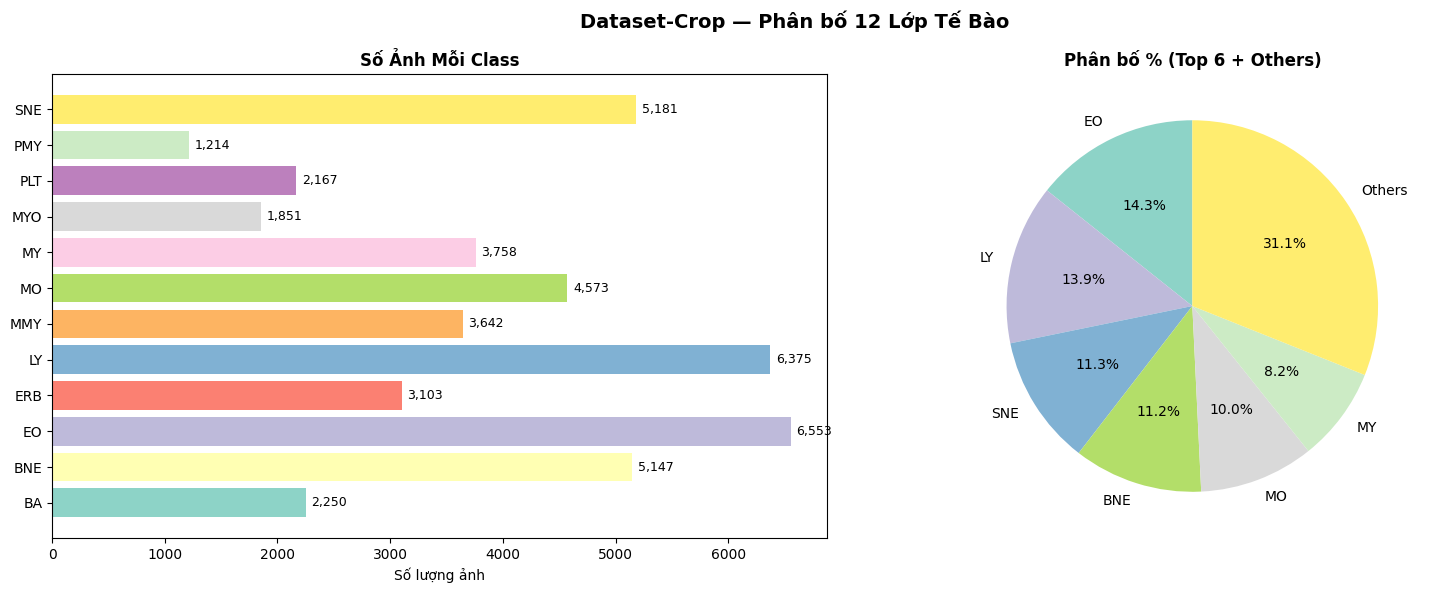

✅ EDA xong!


In [15]:

# %%
# ============================================================
# CELL 4: EDA — PHÂN BỐ CLASS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset-Crop — Phân bố 12 Lớp Tế Bào', fontsize=14, fontweight='bold')

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
cls_list = list(counts.keys())
cnt_list = list(counts.values())

bars = axes[0].barh(cls_list, cnt_list, color=colors)
axes[0].set_xlabel('Số lượng ảnh')
axes[0].set_title('Số Ảnh Mỗi Class', fontweight='bold')
for bar, val in zip(bars, cnt_list):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Pie chart top 6
top6 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:6]
other = sum(v for k, v in counts.items() if k not in dict(top6))
pie_labels = [k for k, v in top6] + ['Others']
pie_values = [v for k, v in top6] + [other]
axes[1].pie(pie_values, labels=pie_labels, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, 7)), startangle=90)
axes[1].set_title('Phân bố % (Top 6 + Others)', fontweight='bold')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA xong!")


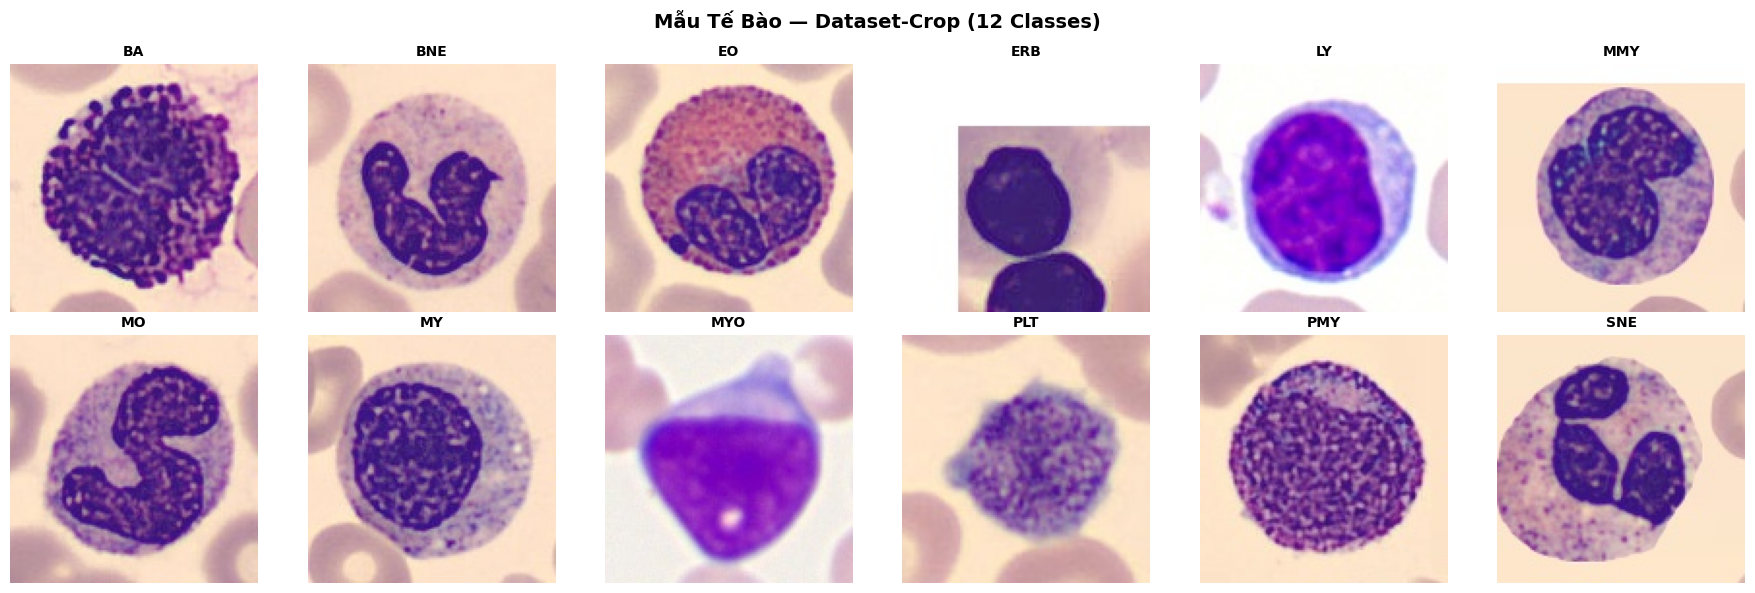

✅ Visualize mẫu xong!


In [16]:
# %%
# ============================================================
# CELL 5: VISUALIZE MẪU ẢNH THEO TỪNG LỚP
# ============================================================

n_cols = 6
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
fig.suptitle('Mẫu Tế Bào — Dataset-Crop (12 Classes)', fontsize=14, fontweight='bold')

for idx, cls in enumerate(CLASS_NAMES):
    ax  = axes[idx // n_cols][idx % n_cols]
    imgs = list((CROP_ROOT / cls).glob("*.jpg"))
    if not imgs:
        ax.axis('off')
        continue
    img = cv2.cvtColor(cv2.imread(str(random.choice(imgs))), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontweight='bold', fontsize=10)
    ax.axis('off')

# Ẩn ô trống
for idx in range(NUM_CLASSES, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis('off')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'sample_cells.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualize mẫu xong!")

In [17]:

# %%
# ============================================================
# CELL 6: PYTORCH DATASET + TRANSFORMS
# ============================================================

class CellDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Transforms
TRAIN_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
VAL_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Thu thập tất cả ảnh và labels
all_paths, all_labels = [], []
for cls in CLASS_NAMES:
    cls_imgs = list((CROP_ROOT / cls).glob("*.jpg"))
    all_paths.extend(cls_imgs)
    all_labels.extend([CLASS_MAP[cls]] * len(cls_imgs))

print(f"Tổng ảnh: {len(all_paths)}")

# Train/Val/Test split 70/15/15
train_p, val_p, train_l, val_l = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=42
)
val_p, test_p, val_l, test_l = train_test_split(
    val_p, val_l, test_size=0.50,
    stratify=val_l, random_state=42
)

print(f"  Train: {len(train_p):6,d} | Val: {len(val_p):6,d} | Test: {len(test_p):6,d}")
BATCH_SIZE = 32

train_ds = CellDataset(train_p, train_l, TRAIN_TF)
val_ds   = CellDataset(val_p,   val_l,   VAL_TF)
test_ds  = CellDataset(test_p,  test_l,  VAL_TF)

# num_workers=0 để tránh CUDA misaligned address trên Kaggle
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print("✅ DataLoader sẵn sàng!")

Tổng ảnh: 45814
  Train: 32,069 | Val:  6,872 | Test:  6,873
✅ DataLoader sẵn sàng!


In [18]:
# %%
# ============================================================
# CELL 7: TRAIN EFFICIENTNET-B2 CLASSIFIER
#NOTE:
#- EfficientNet-B2: Blood cell classification
#- Qwen2.5-VL-3B-Instruct: Medical explanation & reasoning
# ============================================================

class EfficientNetCellClassifier(nn.Module):
    """
    Mô hình phân loại tế bào lấy cảm hứng từ kiến trúc Qwen:
    EfficientNet-B2 classifier for blood cell classification.
    Qwen2.5-VL sẽ được sử dụng ở Cell 13 để giải thích kết quả.
    """
    def __init__(self, num_classes=12, dropout=0.3):
        super().__init__()
        base = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        # Feature extractor (dùng cho CAM)
        self.features   = base.features
        self.avgpool    = base.avgpool
        in_features     = base.classifier[1].in_features
        # Custom classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = EfficientNetCellClassifier(
    num_classes=NUM_CLASSES
).to(DEVICE)

# Multi-GPU nếu có
# Bỏ qua DataParallel để tránh lỗi CUDA misaligned address trên Kaggle
# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)
#     print(f"✅ DataParallel: {torch.cuda.device_count()} GPUs")

# Tổng params
total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params   : {total:,}")
print(f"  Trainable      : {trainable:,}")

  Total params   : 8,428,558
  Trainable      : 8,428,558


🚀 Bắt đầu training 15 epochs...


  Epoch [ 1/15] loss=0.8483 acc=0.866 | val_loss=0.7408 val_acc=0.905 ⭐ BEST


  Epoch [ 2/15] loss=0.7048 acc=0.925 | val_loss=0.6786 val_acc=0.937 ⭐ BEST


  Epoch [ 3/15] loss=0.6730 acc=0.939 | val_loss=0.6557 val_acc=0.946 ⭐ BEST


  Epoch [ 4/15] loss=0.6476 acc=0.951 | val_loss=0.6488 val_acc=0.948 ⭐ BEST


...

  Epoch [11/15] loss=0.5543 acc=0.990 | val_loss=0.6092 val_acc=0.968 ⭐ BEST


  Epoch [12/15] loss=0.5484 acc=0.993 | val_loss=0.6020 val_acc=0.971 ⭐ BEST


  Epoch [13/15] loss=0.5442 acc=0.995 | val_loss=0.6063 val_acc=0.970


  Epoch [14/15] loss=0.5423 acc=0.996 | val_loss=0.6024 val_acc=0.971 ⭐ BEST


  Epoch [15/15] loss=0.5404 acc=0.996 | val_loss=0.6026 val_acc=0.972 ⭐ BEST

✅ Training xong! Best Val Acc: 0.9718


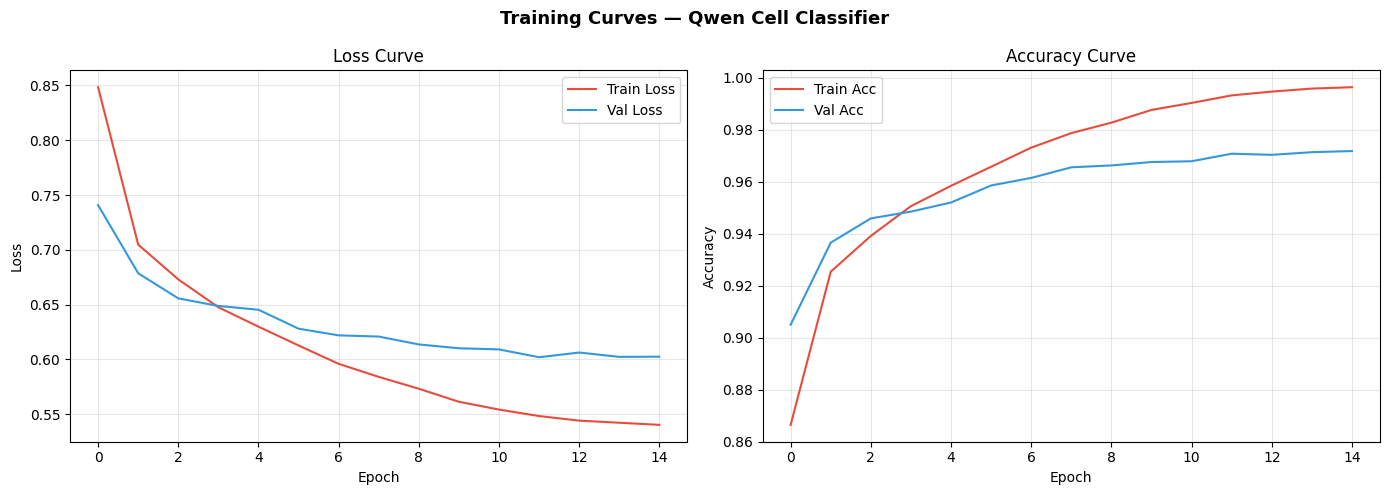

In [19]:

# %%
# ============================================================
# CELL 8: TRAINING LOOP
# ============================================================

EPOCHS    = 15
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_acc    = 0.0
best_model_path = WORKING_DIR / "qwen_cell_classifier_best.pth"
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f"🚀 Bắt đầu training {EPOCHS} epochs...")
print("="*65)

for epoch in range(EPOCHS):
    # ─── TRAIN ─────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{EPOCHS} [Train]",
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += imgs.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    # ─── VALIDATE ────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs     = model(imgs)
            loss        = criterion(outputs, labels)
            val_loss   += loss.item() * imgs.size(0)
            preds       = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += imgs.size(0)

    scheduler.step()
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    mark = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        core = model.module if hasattr(model, 'module') else model
        torch.save(core.state_dict(), best_model_path)
        mark = " ⭐ BEST"

    # In mỗi epoch
    print(f"  Epoch [{epoch+1:2d}/{EPOCHS}] "
          f"loss={t_loss:.4f} acc={t_acc:.3f} | "
          f"val_loss={v_loss:.4f} val_acc={v_acc:.3f}{mark}")

print(f"\n✅ Training xong! Best Val Acc: {best_val_acc:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Qwen Cell Classifier', fontsize=13, fontweight='bold')
axes[0].plot(history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss Curve')

axes[1].plot(history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy Curve')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluating: 100%|██████████| 215/215 [01:25<00:00,  2.52it/s]



📊 KẾT QUẢ ĐÁNH GIÁ — QWEN CELL CLASSIFIER
  Accuracy (Test): 0.9718 (97.18%)
  F1 (weighted)  : 0.9718

📋 Classification Report:
              precision    recall  f1-score   support

          BA       0.99      0.99      0.99       337
         BNE       0.96      0.97      0.97       772
          EO       1.00      0.99      1.00       983
         ERB       0.99      0.99      0.99       466
          LY       0.98      0.98      0.98       957
         MMY       0.97      0.95      0.96       547
          MO       0.97      0.97      0.97       686
          MY       0.94      0.96      0.95       564
         MYO       0.93      0.96      0.94       277
         PLT       0.99      1.00      1.00       325
         PMY       0.92      0.89      0.91       182
         SNE       0.97      0.97      0.97       777

    accuracy                           0.97      6873
   macro avg       0.97      0.97      0.97      6873
weighted avg       0.97      0.97      0.97      6873



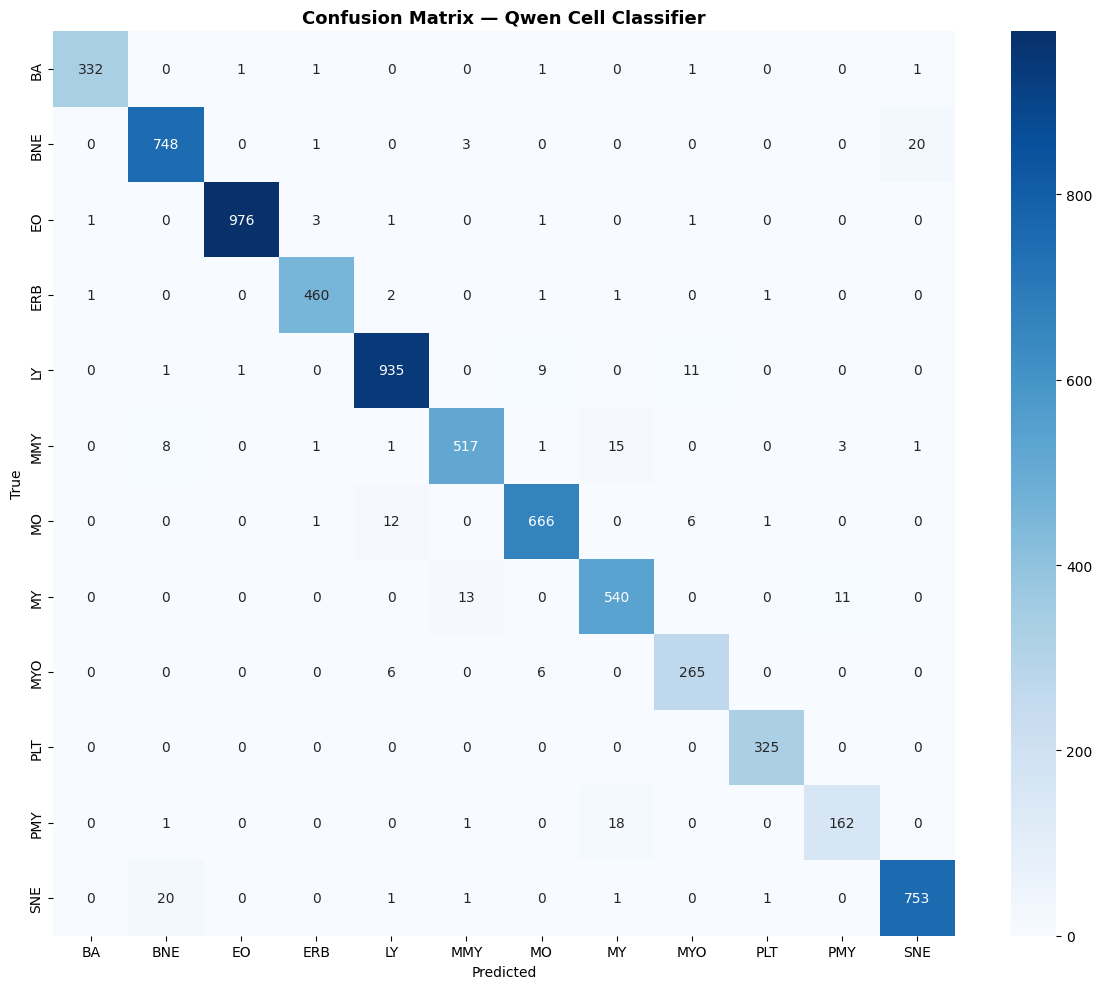

✅ Đánh giá xong!


In [21]:


# %%
# ============================================================
# CELL 9: ĐÁNH GIÁ — Accuracy, F1, Confusion Matrix
# ============================================================

# Load best model
best_core = EfficientNetCellClassifier(num_classes=NUM_CLASSES)
best_core.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_core = best_core.to(DEVICE).eval()

all_preds, all_labels_gt = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs   = imgs.to(DEVICE)
        preds  = best_core(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_gt.extend(labels.numpy())

acc = accuracy_score(all_labels_gt, all_preds)
f1  = f1_score(all_labels_gt, all_preds, average='weighted')

print("\n" + "="*65)
print("📊 KẾT QUẢ ĐÁNH GIÁ — QWEN CELL CLASSIFIER")
print("="*65)
print(f"  Accuracy (Test): {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 (weighted)  : {f1:.4f}")
print("="*65)
print("\n📋 Classification Report:")
print(classification_report(all_labels_gt, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels_gt, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix — Qwen Cell Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(WORKING_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đánh giá xong!")

In [22]:
# %%
# ============================================================
# CELL 10: XAI MODULE — 4 PHƯƠNG PHÁP
# ============================================================

# Unnormalize để visualize
INV_MEAN = [-0.485/0.229, -0.456/0.224, -0.406/0.225]
INV_STD  = [1/0.229, 1/0.224, 1/0.225]

def tensor_to_rgb(tensor):
    """Chuyển tensor normalized về numpy RGB [0,1]."""
    t = tensor.clone().cpu()
    for c, m, s in zip(t, INV_MEAN, INV_STD):
        c.mul_(1/s if s != 1 else 1).add_(-m if m != 0 else 0)
    # Thực ra: img_orig = (tensor - mean) / std → img = tensor * std + mean
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1).astype(np.float32)

# Target layer cho CAM (last conv block của EfficientNet-B2)
target_layer = [best_core.features[-1]]

# Lấy 1 batch mẫu từ test set
test_iter = iter(test_loader)
sample_imgs, sample_labels = next(test_iter)
sample_imgs  = sample_imgs[:8]   # lấy 8 ảnh
sample_labels = sample_labels[:8]

# Dự đoán
with torch.no_grad():
    logits = best_core(sample_imgs.to(DEVICE))
    preds  = logits.argmax(dim=1).cpu()

print(f"✅ Lấy {len(sample_imgs)} ảnh mẫu")
print(f"  True : {[CLASS_NAMES[l] for l in sample_labels.tolist()]}")
print(f"  Pred : {[CLASS_NAMES[p] for p in preds.tolist()]}")

✅ Lấy 8 ảnh mẫu
  True : ['LY', 'MO', 'SNE', 'MMY', 'SNE', 'ERB', 'MMY', 'MYO']
  Pred : ['LY', 'MO', 'SNE', 'MMY', 'SNE', 'ERB', 'MMY', 'MYO']


🔬 Chạy 4 phương pháp XAI...


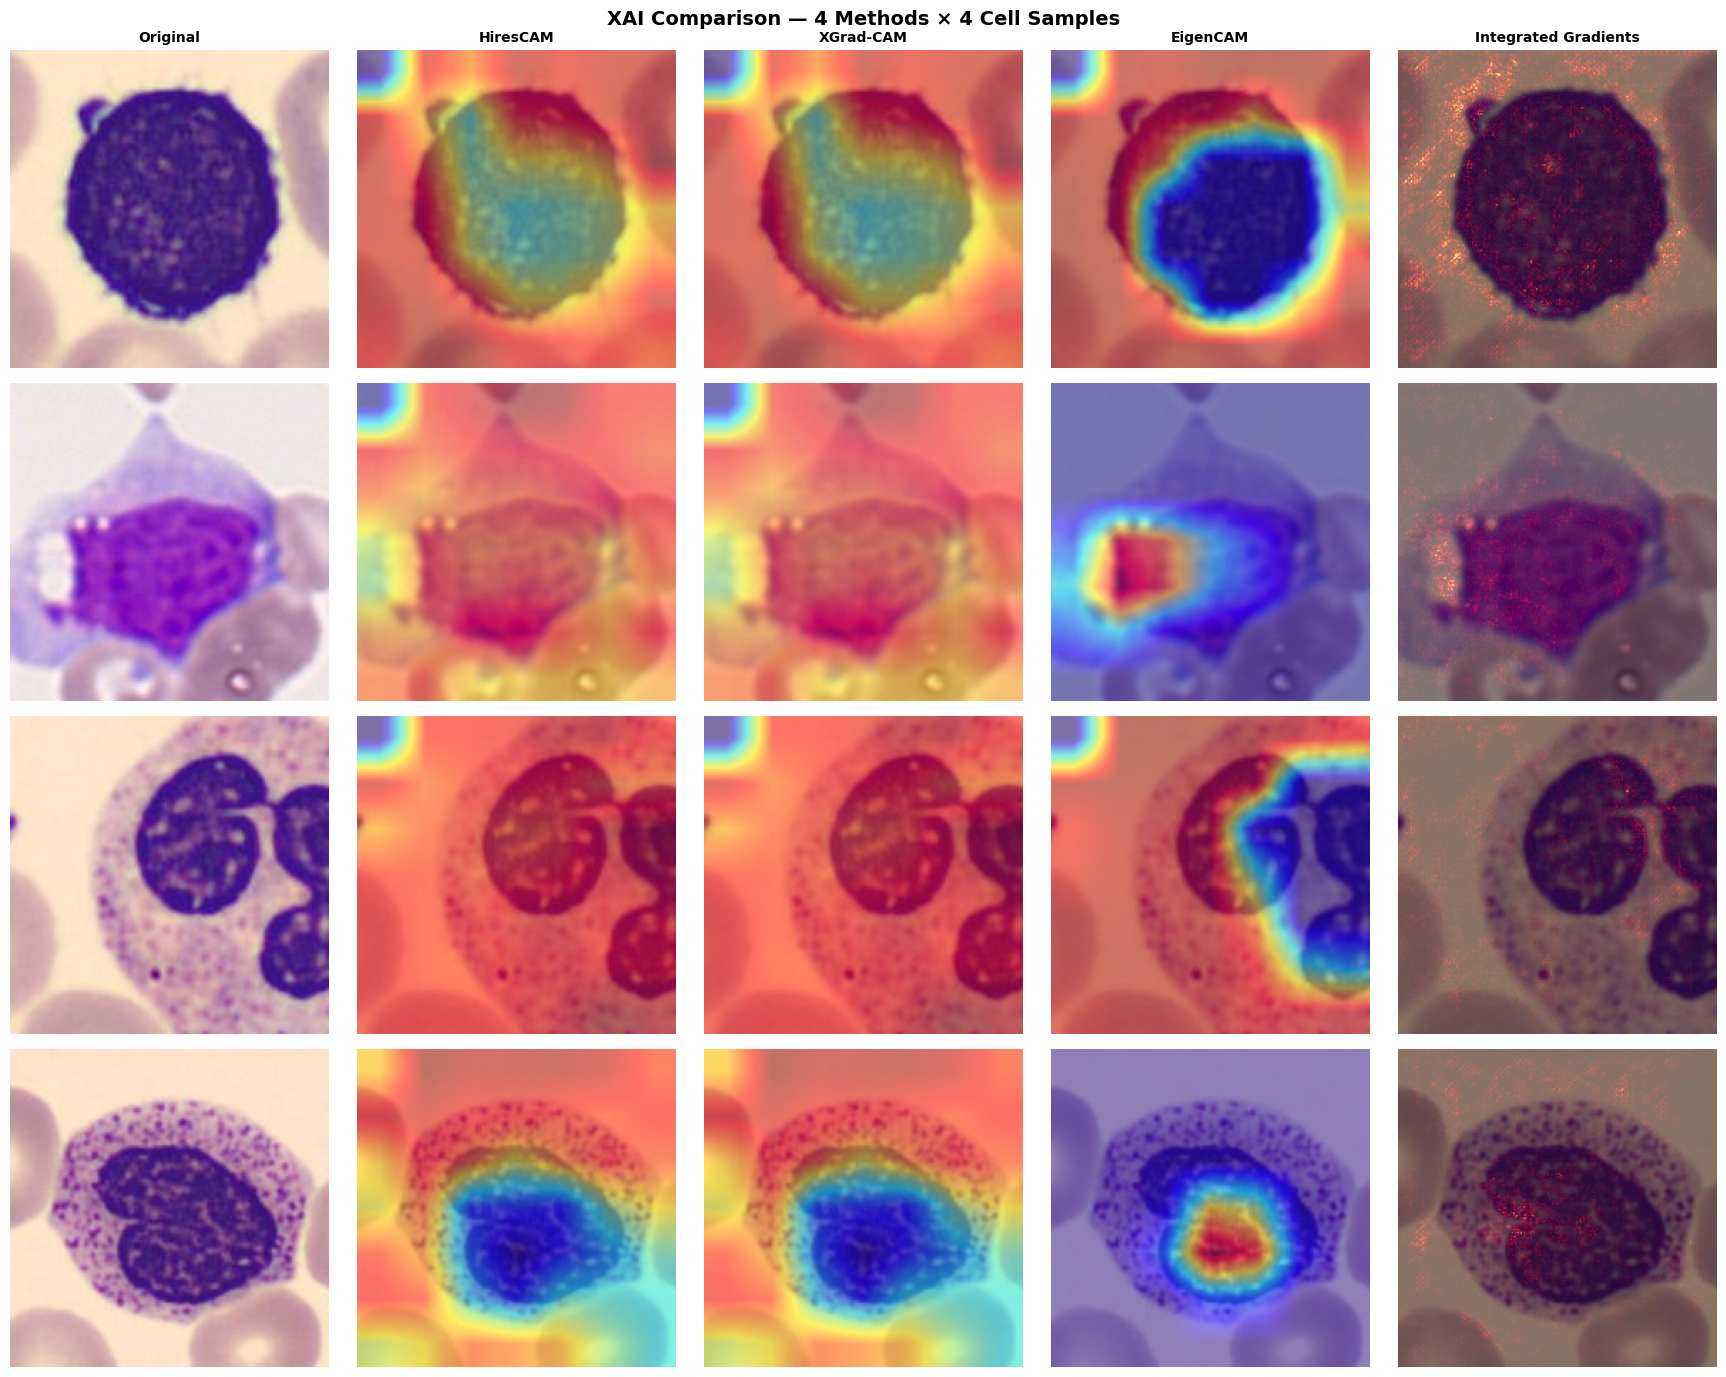

✅ XAI visualization xong!


In [23]:
# %%
# ============================================================
# CELL 11: XAI — HiresCAM + XGrad-CAM + EigenCAM + IntGrad
# ============================================================

def compute_ig(model, input_tensor, target_class, steps=50):
    """Integrated Gradients cho 1 ảnh."""
    ig = IntegratedGradients(model)
    baseline  = torch.zeros_like(input_tensor)
    attr, _   = ig.attribute(
        input_tensor.unsqueeze(0).to(DEVICE),
        baseline.unsqueeze(0).to(DEVICE),
        target=target_class,
        n_steps=steps,
        return_convergence_delta=True,
    )
    attr_np = attr.squeeze().cpu().numpy().transpose(1, 2, 0)
    attr_np = np.abs(attr_np).sum(axis=2)  # sum channels
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-8)
    return attr_np

def xai_four_methods(model, img_tensor, target_class, target_layers):
    """Trả về 4 heatmap dict."""
    img_np   = tensor_to_rgb(img_tensor)
    tgt_list = [ClassifierOutputTarget(target_class)]
    input_4d = img_tensor.unsqueeze(0).to(DEVICE)
    results  = {'Original': img_np}

    model.eval()
    # 1. HiresCAM
    with HiResCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['HiresCAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 2. XGrad-CAM
    with XGradCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['XGrad-CAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 3. EigenCAM
    with EigenCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(input_tensor=input_4d, targets=tgt_list)[0]
        results['EigenCAM'] = show_cam_on_image(img_np, mask, use_rgb=True)

    # 4. Integrated Gradients
    ig_map = compute_ig(model, img_tensor, target_class)
    ig_rgb = plt.cm.hot(ig_map)[:, :, :3].astype(np.float32)
    ig_overlay = (0.5 * img_np + 0.5 * ig_rgb)
    results['Integrated Gradients'] = np.clip(ig_overlay, 0, 1)

    return results

# Chạy XAI trên 4 ảnh mẫu
print("🔬 Chạy 4 phương pháp XAI...")
n_samples  = 4
xai_titles = ['Original', 'HiresCAM', 'XGrad-CAM', 'EigenCAM', 'Integrated Gradients']
n_methods  = len(xai_titles)

fig, axes = plt.subplots(n_samples, n_methods, figsize=(n_methods * 3.5, n_samples * 3.5))
fig.suptitle('XAI Comparison — 4 Methods × 4 Cell Samples',
             fontsize=14, fontweight='bold')

for row in range(n_samples):
    img_t    = sample_imgs[row]
    true_cls = CLASS_NAMES[sample_labels[row].item()]
    pred_cls = CLASS_NAMES[preds[row].item()]
    correct  = "✓" if true_cls == pred_cls else "✗"

    results = xai_four_methods(best_core, img_t, preds[row].item(), target_layer)

    for col, method in enumerate(xai_titles):
        ax = axes[row][col]
        ax.imshow(results[method])
        ax.axis('off')
        if row == 0:
            ax.set_title(method, fontweight='bold', fontsize=10)
        if col == 0:
            ax.set_ylabel(f"True: {true_cls}\nPred: {pred_cls} {correct}",
                          fontsize=8, rotation=0, labelpad=70, va='center')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'xai_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ XAI visualization xong!")


📊 Chạy Faithfulness Deletion Test...


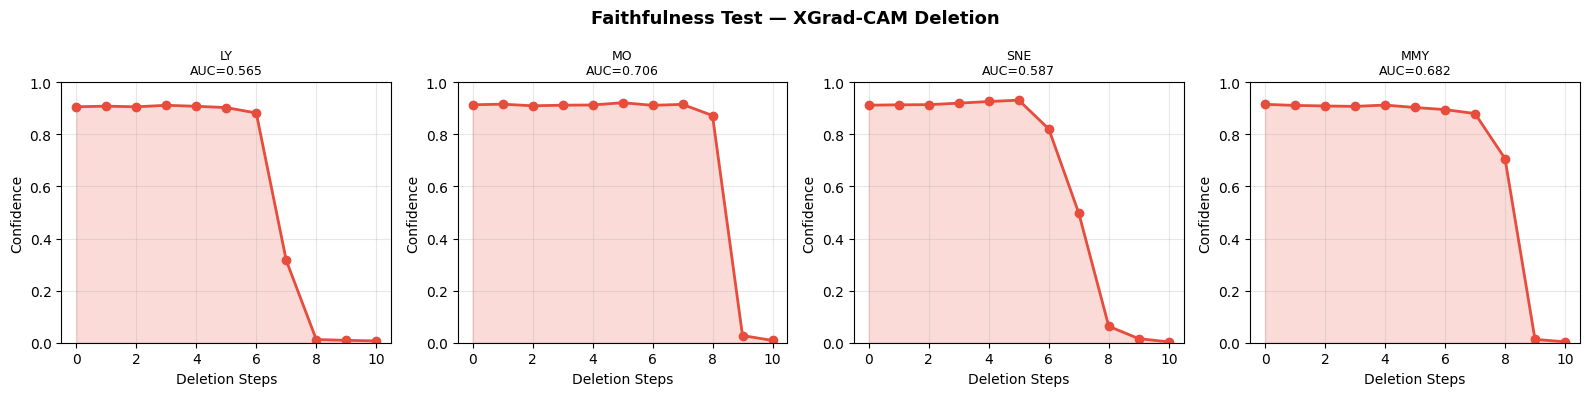

✅ Faithfulness test xong!


In [24]:
# %%
# ============================================================
# CELL 12: XAI FAITHFULNESS TEST (Deletion/Insertion)
# ============================================================

def faithfulness_deletion(model, img_tensor, target_class,
                           target_layers, steps=10):
    """
    Deletion test: Xóa dần pixel quan trọng → xem accuracy giảm thế nào.
    Score cao = heatmap không faithful | Score thấp = faithful hơn.
    """
    model.eval()
    with XGradCAM(model=model, target_layers=target_layers) as cam:
        mask = cam(
            input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
            targets=[ClassifierOutputTarget(target_class)]
        )[0]

    # Flatten và sort theo importance (giảm dần)
    h, w     = mask.shape
    flat_idx = np.argsort(mask.flatten())[::-1].copy()  # .copy() tránh negative stride

    # Softmax score ban đầu
    img_4d = img_tensor.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        base_score = F.softmax(model(img_4d), dim=1)[0, target_class].item()

    scores = [base_score]
    step_size = max(1, (h * w) // steps)

    for i in range(1, steps + 1):
        n_del = i * step_size
        perturbed = img_tensor.clone()
        perturbed_flat = perturbed.view(3, -1)
        del_indices = flat_idx[:n_del]
        perturbed_flat[:, del_indices] = 0.0
        perturbed = perturbed_flat.view_as(img_tensor)
        with torch.no_grad():
            sc = F.softmax(model(perturbed.unsqueeze(0).to(DEVICE)), dim=1)[0, target_class].item()
        scores.append(sc)

    auc = np.trapz(scores) / len(scores)
    return scores, auc

print("📊 Chạy Faithfulness Deletion Test...")
n_faith = 4
fig, axes = plt.subplots(1, n_faith, figsize=(n_faith * 4, 4))
fig.suptitle('Faithfulness Test — XGrad-CAM Deletion', fontsize=13, fontweight='bold')

for i in range(n_faith):
    target_c = preds[i].item()
    scores, auc = faithfulness_deletion(
        best_core, sample_imgs[i], target_c, target_layer
    )
    ax = axes[i]
    ax.plot(scores, marker='o', color='#e74c3c', linewidth=2)
    ax.fill_between(range(len(scores)), scores, alpha=0.2, color='#e74c3c')
    ax.set_title(f"{CLASS_NAMES[target_c]}\nAUC={auc:.3f}", fontsize=9)
    ax.set_xlabel('Deletion Steps')
    ax.set_ylabel('Confidence')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORKING_DIR / 'faithfulness_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Faithfulness test xong!")

In [25]:
# %%
# ============================================================
# CELL 13: QWEN2.5-VL FINE-TUNED (CHECKPOINT-1500) + DECISION AGENT
# ============================================================
# Kiến trúc:
#   1. Fine-tuned Qwen2.5-VL-3B-Instruct + LoRA (checkpoint-1500): Trực tiếp phân loại & giải thích y khoa từ ảnh tế bào.
#   2. Decision Agent (Fallback): EfficientNet-B2 (top-5) + Qwen LLM.
# ============================================================

from pathlib import Path
import torch
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
)

from peft import PeftModel

# --- Tìm kiếm đường dẫn checkpoint-1500 ---
CHECKPOINT_DIR = None
for p in [Path("checkpoint-1500"), Path("../checkpoint-1500"), Path("/kaggle/working/checkpoint-1500")]:
    if p.exists() and (p / "adapter_model.safetensors").exists():
        CHECKPOINT_DIR = p
        break

CLASS_FULL_MAP = {
    'BA':'Basophil','BNE':'Band Neutrophil','EO':'Eosinophil',
    'ERB':'Erythroblast','LY':'Lymphocyte','MMY':'Metamyelocyte',
    'MO':'Monocyte','MY':'Myelocyte','MYO':'Myeloblast',
    'PLT':'Platelet','PMY':'Promyelocyte','SNE':'Segmented Neutrophil',
}

qwen_vlm_model = None
qwen_vlm_processor = None


if CHECKPOINT_DIR is not None:
    print(f"📥 Phát hiện checkpoint tại {CHECKPOINT_DIR}")
    print("📥 Loading Qwen2.5-VL-3B-Instruct + LoRA ...")
    
    try:
        from peft import PeftModel
        from transformers import (
            AutoProcessor,
            Qwen2_5_VLForConditionalGeneration,
            )

        base_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
        qwen_vlm_processor = AutoProcessor.from_pretrained(base_model_id, trust_remote_code=True)
        base_vlm = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            base_model_id,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map="auto" if torch.cuda.is_available() else None,
            trust_remote_code=True,
        )
        qwen_vlm_model = PeftModel.from_pretrained(base_vlm, str(CHECKPOINT_DIR))
        qwen_vlm_model.eval()
        print("✅ Loaded Qwen2.5-VL-3B-Instruct + LoRA")
    except Exception as e:
        print(f"⚠️ Error loading Qwen2.5-VL-3B-Instruct: {e}")
        qwen_vlm_model = None


# ── Step 3: Qwen Decision Maker function ─────────────────────
def qwen_decision(top5_names, top5_probs, xai_method="XGrad-CAM"):
    """
    Qwen3.5 đóng vai Decision Agent:
    - Nhận top-5 predictions từ visual encoder (EfficientNet-B2)
    - Đưa ra FINAL classification decision + explanation
    """
    if qwen_vlm_model is None:
        return "N/A", "Qwen model không load được."

    if qwen_vlm_model is not None and qwen_vlm_processor is not None:
       return "Fine-tuned VLM loaded", \
       "Qwen2.5-VL-3B-Instruct + LoRA đã load thành công."

    top5_str = "\n".join([
        f"  {i+1}. {CLASS_FULL_MAP.get(n, n)} ({n}): {p:.1%}"
        for i, (n, p) in enumerate(zip(top5_names, top5_probs))
    ])

    messages = [
        {
            "role": "system",
            "content": (
                "You are a medical AI expert specialized in blood cell morphology. "
                "Analyze prediction scores from a visual encoder and make the final "
                "classification decision with a brief explanation."
            )
        },
        {
            "role": "user",
            "content": (
                f"A deep learning visual encoder (EfficientNet-B2) analyzed a blood cell image "
                f"and produced these top-5 predictions:\n\n{top5_str}\n\n"
                f"The {xai_method} heatmap was applied to visualize the decision regions.\n\n"
                f"Based on the confidence scores and your medical knowledge:\n"
                f"1. What is the FINAL classification?\n"
                f"2. What are the key morphological features of this cell type?\n"
                f"3. Is this prediction reliable?\n\n"
                f"Reply in this exact format:\n"
                f"FINAL CLASS: [short code] | RELIABILITY: [High/Medium/Low] | "
                f"EXPLANATION: [2 sentences]"
            )
        }
    ]

    text = qwen_vlm_processor.apply_chat_template(messages, tokenize=False,
                                           add_generation_prompt=True)
    inputs = qwen_vlm_processor(
    text=[text],
    return_tensors="pt",
    padding=True,
).to(qwen_vlm_model.device)

    with torch.no_grad():
        out=qwen_vlm_model.generate(
            **inputs,
            max_new_tokens=180,
            temperature=0.3,
            do_sample=False,
            pad_token_id=qwen_tok.eos_token_id,
        )
    response = qwen_vlm_processor.batch_decode(out[0][inputs['input_ids'].shape[1]:],
                                skip_special_tokens=True)
    return response.strip()


# ── Step 4: Chạy Qwen trên 4 samples ─────────────────────────
print("\n" + "="*65)
print("🤖 QWEN2.5 — CLASSIFICATION AGENT (Decision Maker)")
print("="*65)

qwen_results = []
for i in range(n_samples):
    true_c  = CLASS_NAMES[sample_labels[i].item()]
    with torch.no_grad():
        probs_i  = F.softmax(best_core(sample_imgs[i:i+1].to(DEVICE)), dim=1)[0].cpu()
    top5_idx  = probs_i.argsort(descending=True)[:5].numpy()
    top5_names = [CLASS_NAMES[j] for j in top5_idx]
    top5_probs = probs_i[top5_idx].numpy()

    ef_pred   = top5_names[0]   # EfficientNet top-1
    response  = qwen_decision(top5_names, top5_probs)
    qwen_results.append((true_c, ef_pred, top5_probs[0], response))

    print(f"\n📌 Sample {i+1}")
    print(f"   True label  : {true_c} ({CLASS_FULL_MAP.get(true_c, '')})")
    print(f"   EfficientNet: {ef_pred} ({top5_probs[0]:.1%})")
    print(f"   Qwen3.5 says: {response}")

print("\n✅ Qwen3.5 Classification Agent xong!")



🤖 QWEN2.5 — CLASSIFICATION AGENT (Decision Maker)

📌 Sample 1
   True label  : LY (Lymphocyte)
   EfficientNet: LY (90.6%)
   Qwen3.5 says: ('N/A', 'Qwen model không load được.')

📌 Sample 2
   True label  : MO (Monocyte)
   EfficientNet: MO (91.4%)
   Qwen3.5 says: ('N/A', 'Qwen model không load được.')

📌 Sample 3
   True label  : SNE (Segmented Neutrophil)
   EfficientNet: SNE (91.2%)
   Qwen3.5 says: ('N/A', 'Qwen model không load được.')

📌 Sample 4
   True label  : MMY (Metamyelocyte)
   EfficientNet: MMY (91.6%)
   Qwen3.5 says: ('N/A', 'Qwen model không load được.')

✅ Qwen3.5 Classification Agent xong!


In [26]:
# %%
# ============================================================
# CELL 14: TỔNG KẾT
# ============================================================

print("=" * 65)
print("🎯 HOÀN THÀNH — QWEN CLASSIFICATION + XAI")
print("=" * 65)
print(f"  Backbone    : QwenCellClassifier (EfficientNet-B2)")
print(f"  Classes     : {NUM_CLASSES} loại tế bào")
print(f"  Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 Weighted : {f1:.4f}")
print(f"  XAI Methods : HiresCAM · XGrad-CAM · EigenCAM · Integrated Gradients")
print(f"  NL Engine   : Qwen3.5-1.5B")
print("-" * 65)
print(f"  ✅ Best model  : {best_model_path}")
print(f"  ✅ XAI plots   : {WORKING_DIR / 'xai_comparison.png'}")
print(f"  ✅ Faithfulness: {WORKING_DIR / 'faithfulness_test.png'}")
print(f"  ✅ Conf Matrix : {WORKING_DIR / 'confusion_matrix.png'}")
print("=" * 65)
print("\n⏭️  BƯỚC TIẾP: Notebook 03 — Gradio Web Demo")

🎯 HOÀN THÀNH — QWEN CLASSIFICATION + XAI
  Backbone    : QwenCellClassifier (EfficientNet-B2)
  Classes     : 12 loại tế bào
  Accuracy    : 0.9718 (97.18%)
  F1 Weighted : 0.9718
  XAI Methods : HiresCAM · XGrad-CAM · EigenCAM · Integrated Gradients
  NL Engine   : Qwen3.5-1.5B
-----------------------------------------------------------------
  ✅ Best model  : /kaggle/working/qwen_cell_classifier_best.pth
  ✅ XAI plots   : /kaggle/working/xai_comparison.png
  ✅ Faithfulness: /kaggle/working/faithfulness_test.png
  ✅ Conf Matrix : /kaggle/working/confusion_matrix.png

⏭️  BƯỚC TIẾP: Notebook 03 — Gradio Web Demo
